To Develop
==========

**Author:** Marcos Bujosa



$
\newcommand{\R}[1][{}]{{\mathbb{R}}^{#1}}
\newcommand{\Z}[1][{}]{{\mathbb{Z}}^{#1}}
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\getItem}{{\mid}}
\newcommand{\getitemR}[1]{\getItem{#1}}
\newcommand{\getitemL}[1]{{#1}\getItem}
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\elemR}[2]{{#1}^{\phantom{\T}}_{\getitemR{#2}}} 
\newcommand{\elemRP}[2]{{\big(#1\big)}^{\phantom{\T}}_{\getitemR{#2}}} 
\newcommand{\elemRPE}[2]{\big({#1}^{\phantom{\T}}_{\getitemR{#2}}\big)}
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\elemL}[2]  { {\vphantom{#1}}_{ \getitemL{#2}} {#1} } 
\newcommand{\elemLP}[2] { \elemL{\!\big({#1}\big)}{#2} }  
\newcommand{\elemLPE}[2]{ \big(\elemL{#1}{#2}\big) }
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\Vect}[2][{}]{{\boldsymbol{#2}}_{#1}}
\newcommand{\eleVR}[2]  {\elemR  {\Vect{#1}}{#2}}      % con subindices
\newcommand{\eleVRP}[2] {\elemRP {\Vect{#1}}{#2}}      % con subindices y paréntesis interior
\newcommand{\eleVRPE}[2]{\elemRPE{\Vect{#1}}{#2}}      % con subindices y paréntesis exterior
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\VectC}[2]  {\elemR  {\Mat{#1}}{#2}}         % con subindices
\newcommand{\VectCP}[2] {\elemRP {\Mat{#1}}{#2}}       % con subindices y paréntesis
\newcommand{\VectCPE}[2]{\elemRPE{\Mat{#1}}{#2}}       % con subindices y paréntesis exterior
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\VectF}[2]  {\elemL  {\Mat{#1}}{#2}}         % con subindices
\newcommand{\VectFP}[2] {\elemLP {\Mat{#1}}{#2}}       % con subindices y paréntesis
\newcommand{\VectFPE}[2]{\elemLPE{\Mat{#1}}{#2}}       % con subindices y paréntesis exterior
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\newcommand{\mat}[1]{\mathbf{#1}}
%\newcommand{\mat}[1]{\boldsymbol{#1}}                 % hace cursiva, no me gusta para matriz
\newcommand{\Mat} [2][{}]{{\mat{#2}}_{#1}} 
\newcommand{\T}{\intercal}
\newcommand{\MatT}[2][{}]{{\mat{#2}}^{\T}_{#1}}
\newcommand{\VectCC}[2][{}]   {\elemRR {\Mat{#2}}{#1}}   % con ()
\newcommand{\VectCCC}[2][{}]  {\elemRRR{\Mat{#2}}{#1}}   % con texto "col"
%SELECCIÓNA de FILAS y COlUMNAS DE UNA MATRIZ TRANSPUESTA PARA GENERAR UN VECTOR DE Rn
\newcommand{\VectTC}[2][{}]   {\elemR{\MatT{#2}\!}{#1}}  % con subindices
\newcommand{\VectTCC}[2][{}]  {\elemRR{ \MatT{#2}}{#1}}  % con ()
\newcommand{\VectTCCC}[2][{}] {\elemRRR{\MatT{#2}}{#1}}  % con texto "col"
\newcommand{\dotprod}[2][{}] {\Vect{#1}\cdot\Vect{#2}}
\newcommand{\concat}{\mathbin{-\mkern-9.5mu\lVert}}
\newcommand{\SEL}[2] { \Mat{#1}\Vect{x}=\Vect{#2} }
\newcommand{\EV}[1]{\mathcal{#1}}
\newcommand{\SV}[1]{\mathsf{#1}}
$

To use [NAcAL](https://github.com/mbujosab/nacallib), it is necessary to import the module `nacal`.



In [1]:
from nacal import *

There are many things left to explore with NAcAL. Instead of following the book, I will present some topics. I will develop this notebook further in the future.



## Solution of homogeneous linear equation systems



For example, let the matrix be



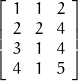

In [2]:
A = Matrix([[1,1,2],[2,2,4],[3,1,4],[4,1,5]])
A

Let's apply elimination from left to right by columns to obtain a pre-echelon form of the matrix:



In [3]:
K = A.K(True)

<IPython.core.display.Math object>

Clearly, the last column is a linear combination of the previous ones. To find the linear combination, we just need to remember that 
$$
\Mat{K}
=
\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{A}
=
\Mat{A}
\big(
\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}
\big)
$$
therefore, if $\elemR{\Mat{K}}{j}=\Vect{0}$, the $j$-th column of $\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}$ is a vector in the null space of $\Mat{A}$
since
$$
 \elemR{\Mat{K}}{j} = \Mat{A} \elemRP{\Mat[\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}]{I}}{j}=\Vect{0}.
$$

Thus, we create a list with the indices of the null columns of $\Mat{K}$:



In [4]:
indiceColumnasNulasdeK = [j for j,c in enumerate(K, 1) if c.es_nulo()]
indiceColumnasNulasdeK

[3]

To calculate $\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}$, we need to know the sequence ${\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}$ of elementary transformations that we have applied to the columns of $\Mat{A}$ to obtain the pre-echelon form $\Mat{K}$. This sequence is stored in the attribute `TrC` of `K`:



In [5]:
K.TrC

T([(-1, 1, 2), (-2, 1, 3), (-1, 2, 3)])

For brevity, let’s denote the matrix $\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}$ as $\Mat{E}$:



In [6]:
E = I( A.n ) & K.TrC

The columns of $\Mat{E}$ whose indices appear in `indiceColumnasNulasdeK` are solutions to the system $\Mat{A}\Vect{x}=\Vect{0}$. In this case:



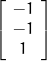

In [7]:
E|indiceColumnasNulasdeK

Let us verify this



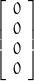

In [8]:
A * (E|indiceColumnasNulasdeK)

## Solution of homogeneous linear equation systems with `Homogenea`



The class `Homogenea` solves homogeneous linear equation systems following the previous procedure. 
The required argument is a system of vectors (generally a matrix). 
The output it shows is the null space associated with the system of vectors. 
If this subspace only contains the zero vector, it shows the set that contains this vector. For example, if the argument is a full-rank column matrix like the identity matrix, we obtain:



In [9]:
Homogenea(I(4))

Combinaciones lineales de (Sistema([Vector([0, 0, 0, 0]);]))

If the columns of the matrix are linearly dependent, it indicates that the set of vectors in the null space is the linear span (or span) of the system containing the special solutions (those that we find through column elimination from left to right using the procedure described above):



In [10]:
Homogenea(A)

Combinaciones lineales de (Sistema([Vector([-1, -1, 1]);]))

When we provide a second argument that is not `0` or `False`, it will show us the steps taken to the resolution. 
To display the steps, it follows the same process that we learned in class, stacking the system over an identity matrix of order equal to the number of elements of the system given as an argument (normally the number of columns of the matrix).



In [11]:
Homogenea(A, True)

<IPython.core.display.Math object>

Combinaciones lineales de (Sistema([Vector([-1, -1, 1]);]))

### Attributes of `Homogenea`



The class `Homogenea` has various attributes. 

-   `enulo` is the null space associated with the system given as an argument. It is an object of the class `SubEspacio` of nacal.
-   `base` is a basis of the null space
-   `sgen` is a generating system of the null space (it is what nacal uses to express the subspace with parametric equations). It is equal to `base` (except when the dimension of the null space is 0; in that case `base` is an empty system while `sgen` is a system with a single zero vector).
-   `determinado` is 1 when the dimension of the null space is 0 (and 0 otherwise).
-   `pasos` is a list with two sublists: the first contains the transformations applied to the rows (empty if operating on columns) and the second sublist contains the transformations applied to the columns.
-   `TrF` is an object of the class `T` with the transformations applied to the rows (empty if operating on columns)
-   `TrC` is an object of the class `T` with the transformations applied to the columns.
-   `tex` is a string with the $\LaTeX{}$ code necessary to display the step-by-step resolution: it shows the stacked system over an identity matrix of the same order as the number of elements of the system (with a horizontal line separating the system and the identity matrix). The steps taken in applying the necessary elementary transformations to obtain a pre-echelon system are shown (over the horizontal line), and the successive matrices obtained by applying the same steps to the columns of the identity matrix (below).

Let’s explore it with various examples.



#### Undetermined system



In [12]:
SistEcuacionesH1 = Homogenea(A)
SistEcuacionesH1.enulo

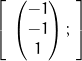

In [13]:
SistEcuacionesH1.base

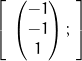

In [14]:
SistEcuacionesH1.sgen

In [15]:
SistEcuacionesH1.determinado

False

In [16]:
SistEcuacionesH1.pasos

[[], [T([(-1, 1, 2), (-2, 1, 3)]), T([(-1, 2, 3)])]]

In [17]:
SistEcuacionesH1.TrC

T([(-1, 1, 2), (-2, 1, 3), (-1, 2, 3)])

#### Determined system



In [18]:
SistEcuacionesH2 = Homogenea( Matrix([[1,1],[1,1],[1,2]]), True)

<IPython.core.display.Math object>

In [19]:
SistEcuacionesH2.enulo

In [20]:
SistEcuacionesH2.base

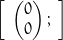

In [21]:
SistEcuacionesH2.sgen

In [22]:
SistEcuacionesH2.determinado

True

In [23]:
SistEcuacionesH2.pasos

[[], [T([(-1, 1, 2)])]]

In [24]:
SistEcuacionesH2.TrC

T([(-1, 1, 2)])

## Solution of generic linear equation systems



For example, let the matrix be



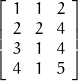

In [25]:
A = Matrix([[1,1,2],[2,2,4],[3,1,4],[4,1,5]])
A

and the vectors



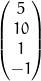

In [26]:
b = Vector([5,10,1,-1])
b

and



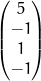

In [27]:
d = Vector([5,-1,1,-1])
d

#### Example of a compatible system



Let's solve $\Mat{A}\Vect{x}=\Vect{b}$. 
The system has a solution if $\Vect{b}$ is equal to some linear combination of the columns of $\Mat{A}$. If $\Vect{x}$ consists of the parameters of any of those linear combinations, then $\Mat{A}\Vect{x}-\Vect{b}=\Vect{0}$; that is, if adding $\Mat{A}\Vect{x}$ to $-\Vect{b}$ gives us a null vector, then $\Vect{x}$ is a solution to the system, since in that case $\Mat{A}\Vect{x}=\Vect{b}$. 

First, we expand $\Mat{A}$ with an additional column.



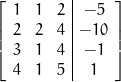

In [28]:
M = A.amplia(-b, 1)
M

Now we pre-echelon the augmented matrix, that is, we add to the right column combinations of the columns on the left, attempting to generate zeros to the right of each pivot:



In [29]:
K = M.K(1)

<IPython.core.display.Math object>

Since the last two columns have been nullified, we know that the last column of $\Mat{A}$ is a linear combination of the first two (as we saw earlier). Now, what we are interested in is that the last column of the augmented matrix has also been nullified. Therefore, we now know that $\Vect{b}$ is a linear combination of the columns of $\Mat{A}$; that is, the system has a solution.

To find a solution, we reason in a similar way as we did earlier. 
Again, we remember that 
$$
\Mat{K}
=
\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{M}
=
\Mat{M}
\big(
\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}
\big)
$$
therefore, if the last column $\elemR{\Mat{K}}{n}=\Vect{0}$, then
$$
 \elemR{\Mat{K}}{n} = \Mat{M} \elemRP{\Mat[\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}]{I}}{n}=\Vect{0}.
$$

To calculate $\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}$ we need to know the sequence ${\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}$ of elementary transformations that we have applied to the columns of $\Mat{M}$ in order to obtain the pre-echelon form $\Mat{K}$. As before, this sequence is stored in the attribute `TrC` of the pre-echelon matrix `K`:



In [30]:
K.TrC

T([(-1, 1, 2), (-2, 1, 3), (5, 1, 4), (-1, 2, 3), (7, 2, 4)])

For brevity, let’s denote the matrix $\Mat[{\mathbf{\tau}_{1}\dots\mathbf{\tau}_{k}}]{I}$ as $\Mat{E}$:



In [31]:
E = I( A.m ) & K.TrC

So that the last column of $\Mat{E}$ is such that when multiplied by the augmented matrix, we get a null vector:



In [32]:
M * (E|0)

Thus, the last column of $\Mat{E}$ gives us a linear combination of the columns of $\Mat{A}$ and the vector $-\Vect{b}$ that is zero, that is



In [33]:
operaciones = "+".join(['(' + (latex((E|0)|i)) + ')' + latex(M|i) for i,c in enumerate(M,1)])
display(Math(operaciones + '=' + latex(V0(M.m))))

<IPython.core.display.Math object>

That is, as the last column of $\Mat{M}$ is $-\Vect{b}$, it means that



In [34]:
operaciones = "+".join(['(' + (latex((E|0)|i)) + ')' + latex(M|i) for i,_ in enumerate(A,1)])
display(Math(operaciones + '=(' + latex((E|0)|0) + r')\Vect{b}'))

<IPython.core.display.Math object>

(it is important to consider the coefficient that occupies the last position of the last column of $\Mat{E}$, as it indicates whether the linear combination on the left equals $\Vect{b}$ or a multiple of $\Vect{b}$).

The complete solution is the set of vectors that are of the form: the particular solution we have found plus any vector from the null space of the coefficient matrix (i.e., an affine space).



#### Example of an incompatible system



Let’s try to solve $\SEL{A}{d}$. First, we expand $\Mat{A}$ with $-\Vect{d}$ as an additional last column.



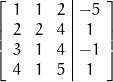

In [35]:
N = A.amplia(-d, 1)
N

Now we pre-echelon the augmented matrix, that is, we add to the right column combinations of the columns on the left, attempting to generate zeros to the right of each pivot:



In [36]:
K = N.K(1)

<IPython.core.display.Math object>

Since the last column of the pre-echelon form is non-null, we know that the last column of $\Mat{M}$ (the vector $\Vect{d}$) is not a linear combination of the first columns (the columns of $\Mat{A}$); that is, the system has no solution (it is incompatible).



## Solution of linear equation systems with `SEL`



The class `SEL` (System of Linear Equations) solves linear equation systems. The arguments it needs are a system of vectors (generally a matrix) and a vector from the right-hand side (of the same type as the elements of the given system). 
If we add a third argument that is not `0` or `False`, it will show us the steps taken to the resolution, just as we have learned in class.

For example, let the matrix be



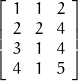

In [37]:
A = Matrix([[1,1,2],[2,2,4],[3,1,4],[4,1,5]])
A

and the vectors



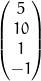

In [38]:
b = Vector([5,10,1,-1])
b

and



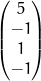

In [39]:
d = Vector([5,-1,1,-1])
d

Let’s solve $\Mat{A}\Vect{x}=\Vect{b}$



In [40]:
SEL(A,b)

Vector([-2, 7, 0]) + Combinaciones lineales de (Sistema([Vector([-1, -1, 1]);]))

That is, the system has infinitely many solutions.

Let’s see that, indeed, in the augmented matrix, the last column becomes null (and therefore, the vector $\Vect{b}$ is a linear combination of the columns of $\Mat{A}$).



In [41]:
SEL(A,b, True)   # where True is to show us the steps

<IPython.core.display.Math object>

Vector([-2, 7, 0]) + Combinaciones lineales de (Sistema([Vector([-1, -1, 1]);]))

Now let’s solve $\Mat{A}\Vect{x}=\Vect{d}$



In [42]:
SEL(A,d)

set() + Combinaciones lineales de (Sistema([Vector([-1, -1, 1]);]))

As can be seen, the system has no solution (in other words: the set of solutions is empty, $\emptyset$).

Let’s verify that, indeed, in the augmented matrix, the last column does NOT become null (and therefore, the vector $\Vect{d}$ is NOT a linear combination of the columns of $\Mat{A}$).



In [43]:
SEL(A,d, True)   # where True is to show us the steps

<IPython.core.display.Math object>

set() + Combinaciones lineales de (Sistema([Vector([-1, -1, 1]);]))

### Attributes of `SEL`



The class `SEL` has various attributes. 

-   `eafin` is the set of solutions. There are two cases:
    -   If the set has infinitely many solutions, it is an affine space (class `EAfin` of nacal).
    -   If there is no solution, it is an empty set.
-   `solP` is a particular solution.
    -   If the set has infinitely many solutions, it is the vector used to express the parametric equations.
    -   If there is no solution, it is an empty set.
-   `base` is a basis of the null space of the coefficient matrix (it is the one used to express the parametric equations).
-   `sgen` is a generating system of the null space of the coefficient matrix (it is the one used to express the parametric equations). It is equal to `base` unless the dimension of the null space is 0; in that case, `sgen` is a system with a single zero vector.
-   `determinado` is 1 when the dimension of the null space is 0 and 0 otherwise.
-   `pasos` is a list with two sublists: the first contains the transformations applied to the rows (empty if operating on columns) and the second sublist contains the transformations applied to the columns.
-   `TrF` is an object of the class `T` with the transformations applied to the rows (empty if operating on columns).
-   `TrC` is an object of the class `T` with the transformations applied to the columns.
-   `tex` is a string with the $\LaTeX{}$ code for the step-by-step resolution.

Let’s explore it with various examples.



#### Undetermined compatible system



In [44]:
SistEcuaciones1 = SEL(A, b, True)

<IPython.core.display.Math object>

When we request `eafin` it shows us two representations: the first with parametric equations, and the second with Cartesian ones:



In [45]:
SistEcuaciones1.eafin

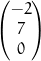

In [46]:
SistEcuaciones1.solP

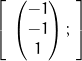

In [47]:
SistEcuaciones1.base

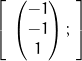

In [48]:
SistEcuaciones1.sgen

In [49]:
SistEcuaciones1.determinado

False

In [50]:
SistEcuaciones1.pasos

[[], [T([(-1, 1, 2), (-2, 1, 3), (5, 1, 4)]), T([(-1, 2, 3), (7, 2, 4)])]]

In [51]:
SistEcuaciones1.TrC

T([(-1, 1, 2), (-2, 1, 3), (5, 1, 4), (-1, 2, 3), (7, 2, 4)])

#### Incompatible system



Now with a system with no solution



In [52]:
SistEcuaciones2 = SEL(A, d, True)

<IPython.core.display.Math object>

When we request `eafin`, it shows us two representations: the first with parametric equations, and the second with Cartesian ones:



In [53]:
SistEcuaciones2.eafin

set()

In [54]:
SistEcuaciones2.solP

set()

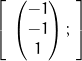

In [55]:
SistEcuaciones2.base

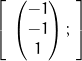

In [56]:
SistEcuaciones2.sgen

In [57]:
SistEcuaciones2.determinado

False

In [58]:
SistEcuaciones2.pasos

[[], [T([(-1, 1, 2), (-2, 1, 3), (5, 1, 4)]), T([(-1, 2, 3), (7, 2, 4)])]]

In [59]:
SistEcuaciones2.TrC

T([(-1, 1, 2), (-2, 1, 3), (5, 1, 4), (-1, 2, 3), (7, 2, 4)])

#### Determined compatible system



In [60]:
SistEcuaciones3 = SEL(I(3), Vector([1,2,3]), True)

<IPython.core.display.Math object>

When we request `eafin`, it shows us two representations: the first with parametric equations, and the second with Cartesian ones:



In [61]:
SistEcuaciones3.eafin

In [62]:
SistEcuaciones3.solP

In [63]:
SistEcuaciones3.base

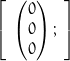

In [64]:
SistEcuaciones3.sgen

In [65]:
SistEcuaciones3.determinado

True

In [66]:
SistEcuaciones3.pasos

[[], [T([(1, 1, 4)]), T([(2, 2, 4)]), T([(3, 3, 4)])]]

In [67]:
SistEcuaciones3.TrC

T([(1, 1, 4), (2, 2, 4), (3, 3, 4)])

#### Incompatible with trivial null space



In [68]:
SistEcuaciones4 = SEL( I(3)|(1,2), Vector([1,2,3]), True)

<IPython.core.display.Math object>

When we request `eafin`, it shows us two representations: the first with parametric equations, and the second with Cartesian ones:



In [69]:
SistEcuaciones4.eafin

set()

In [70]:
SistEcuaciones4.solP

set()

In [71]:
SistEcuaciones4.base

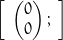

In [72]:
SistEcuaciones4.sgen

In [73]:
SistEcuaciones4.determinado

True

In [74]:
SistEcuaciones4.pasos

[[], [T([(1, 1, 3)]), T([(2, 2, 3)])]]

In [75]:
SistEcuaciones4.TrC

T([(1, 1, 3), (2, 2, 3)])

## Other equation systems



This method is valid even with other types of finite-dimensional vector spaces. For example, the 3 by 2 matrices.

Let the following matrices be:



In [76]:
A = Matrix([[1,2],[1,1],[0,1]])
B = Matrix([[1,1],[1,4],[1,1]])
D = Matrix([[2,3],[2,5],[1,2]])
C = Matrix([[0,1],[1,0],[0,0]])

With these, we can construct the following system



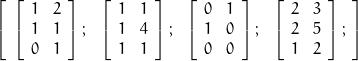

In [77]:
S = Sistema([A,B,C,D])
S

The set of its linear combinations is a subspace. We can ask NAcAL to show us some parametric equations and others Cartesian ones for this subspace.



In [78]:
V = SubEspacio(S)
V

(where $vec(\Mat{M})$ is the vector obtained by stacking the columns of the matrix $\Mat{M}$ into a single vector).

Let’s consider the matrix



In [79]:
F = Matrix([Vector([6, 8, 2]), Vector([12, 12, 6])])

The NAcAL library uses the Cartesian equations from above to check whether a given vector (in this example, this vector is a matrix) belongs to, or not, the vector subspace corresponding to these equations (in this case, a vector space whose elements are matrices).
For example, we can ask if $\Mat{F}$ is an element of $\EV{V}$



In [80]:
F in SubEspacio(S)

True

Since it is true that $\Mat{F}$ belongs to the subspace, we can attempt to solve $\SV{S}\Vect{x}=\Mat{F}$:



In [81]:
SEL(S, F, True)

<IPython.core.display.Math object>

Vector([4, 2, 2, 0]) + Combinaciones lineales de (Sistema([Vector([-1, -1, 0, 1]);]))

This result tells us two things: how to combine the matrices of $\SV{S}$ to obtain null matrices:



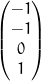

In [82]:
n = SEL(S, F).base|1
n

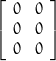

In [83]:
S * n

and how to combine the matrices of $\SV{S}$ to obtain $\Mat{F}$.



In [84]:
xp = SEL(S, F).solP
xp

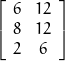

In [85]:
S * xp

But then it is also a solution



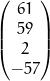

In [86]:
v = xp+-57*n
v

as can be checked:



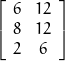

In [87]:
S * v

that is



In [88]:
operaciones = "+".join(['(' + latex(c) + ')' + latex(S|i) for i,c in enumerate(v,1)])
display(Math(operaciones + '=' + latex(F)))

<IPython.core.display.Math object>

## The four fundamental spaces



Let the matrix be



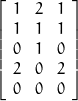

In [89]:
A = Matrix([[1,2,1],[1,1,1],[0,1,0],[2,0,2],[0,0,0]])
A

Viewed as a system of vectors it is



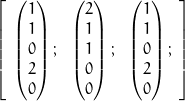

In [90]:
A.sis()

What space does this list of columns generate?



In [91]:
Cols = SubEspacio( A.sis() )
Cols

What is its null space?



In [92]:
Enulo = SubEspacio( A )
Enulo

Therefore, its row space is



In [93]:
Fila = SubEspacio( (~A).sis() )
Fila

or in other words, the orthogonal complement of the null space



In [94]:
~Enulo

And its left null space is



In [95]:
EnuloIzda = SubEspacio( ~A )
EnuloIzda

or in other words, the orthogonal complement of the column space



In [96]:
~Cols

The attribute `Rn` indicates for whom the subspaces belong



In [97]:
print(Cols.Rn)
print(EnuloIzda.Rn)
print(Fila.Rn)
print(Enulo.Rn)

5
5
3
3


$\R[5]$ is the vector space generated by the 5 columns of the identity matrix of order 5



In [98]:
R5 = SubEspacio( I(5).sis() )

Let’s see that $\R[5]$ is the direct sum of the column space and the left null space of matrix $\Mat{A}$. On one hand



In [99]:
R5 == Cols + EnuloIzda

True

and their intersection contains only the zero



In [100]:
Cols & EnuloIzda

See how the dimensions match



In [101]:
Sistema([Cols.dim, EnuloIzda.dim, (Cols+EnuloIzda).dim])

**Exercise**: *Repeat these checks, but now with the row space and the null space of the matrix $\Mat{A}$ to see that their direct sum is $\R[3]$.*



## Determinant



In [102]:
A = Matrix([
    [2, 0, 3, 2],
    [5, 1, 2, 4],
    [3, 0, 1, 2],
    [5, 3, 2, 1]])

In [103]:
A.determinante()

29

In [104]:
Determinante(A, True)

<IPython.core.display.Math object>

Valor del determinante: 29